<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/optimization_regularization/experiment_optimization_learning_rate_scheduler_gradient_clipping_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# LEVEL 1: BAD LR (UNSTABLE TRAINING)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

X = torch.randn(500, 20)
y = (X.sum(dim=1) > 0).long()

model = nn.Sequential(
    nn.Linear(20, 64),
    nn.ReLU(),
    nn.Linear(64, 2)
)

optimizer = optim.Adam(model.parameters(), lr=1.0)  # ❌ too high
loss_fn = nn.CrossEntropyLoss()

loss_history_bad = []

for epoch in range(30):
    optimizer.zero_grad()

    output = model(X)
    loss = loss_fn(output, y)

    loss.backward()
    optimizer.step()

    loss_history_bad.append(loss.item())

In [2]:
optimizer = optim.Adam(model.parameters(), lr=0.001)  # ✅ stable

In [3]:
# ============================================
# LEVEL 3: LR SCHEDULER
# ============================================

model_sched = nn.Sequential(
    nn.Linear(20, 64),
    nn.ReLU(),
    nn.Linear(64, 2)
)

optimizer = optim.Adam(model_sched.parameters(), lr=0.01)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

loss_history_sched = []

for epoch in range(30):
    optimizer.zero_grad()

    output = model_sched(X)
    loss = loss_fn(output, y)

    loss.backward()
    optimizer.step()

    scheduler.step()  # 🔥 update LR

    loss_history_sched.append(loss.item())

In [4]:
# ============================================
# LEVEL 4: GRADIENT CLIPPING
# ============================================

model_clip = nn.Sequential(
    nn.Linear(20, 64),
    nn.ReLU(),
    nn.Linear(64, 2)
)

optimizer = optim.Adam(model_clip.parameters(), lr=0.01)

loss_history_clip = []

for epoch in range(30):
    optimizer.zero_grad()

    output = model_clip(X)
    loss = loss_fn(output, y)

    loss.backward()

    # 🔥 key line
    torch.nn.utils.clip_grad_norm_(model_clip.parameters(), max_norm=1.0)

    optimizer.step()

    loss_history_clip.append(loss.item())

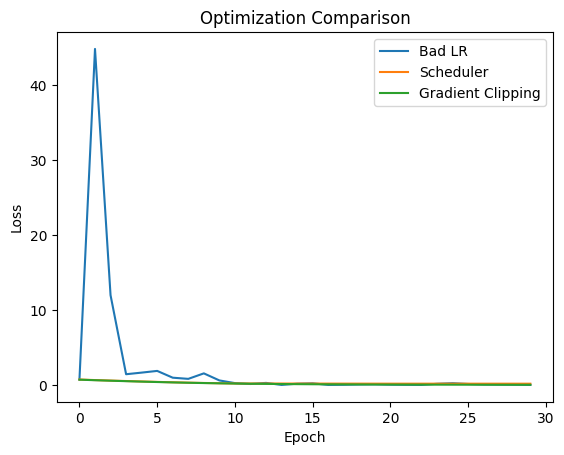

In [6]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(loss_history_bad, label="Bad LR")
plt.plot(loss_history_sched, label="Scheduler")
plt.plot(loss_history_clip, label="Gradient Clipping")

plt.legend()
plt.title("Optimization Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()